# Productivity of Inflation-Targeting Countries (Non-LAC5)

This notebook replicates the productivity-process estimation from `LAC5_prod.ipynb` for
nine non-LAC5 countries that have adopted Inflation Targeting (IT) regimes. The analysis
covers countries from East Asia, Southeast Asia, South Asia, the Middle East, and Africa,
providing cross-regional variation in economic development levels.

The methodology is identical to the LAC5 notebook:
1. Splice long-run (10-Sector Dataset) with recent (ETD) productivity series.
2. Apply the Hamilton (2018) filter to extract the cyclical component.
3. Estimate an AR(1) process for the cycle and report persistence and innovation variance.

**Data availability note**: Israel and Turkey are not in the 10-Sector Dataset and therefore
use only the ETD series (1990–2018). Their productivity levels are in 2015 constant USD,
while the seven countries with both datasets report levels in 2005 constant USD. This
unit difference does not affect growth rates, detrended cycles, or AR(1) parameters.

## Country Selection

| Code | Country      | IT Adopted | Region          | Income level   | Data sources          |
|------|--------------|-----------|-----------------|----------------|-----------------------|
| ISR  | Israel       | 1991      | Middle East     | High           | ETD 1990–2018 only    |
| KOR  | South Korea  | 1998      | East Asia       | High           | 10SD 1950–2011 + ETD  |
| ZAF  | South Africa | 2000      | Africa          | Upper-middle   | 10SD 1960–2011 + ETD  |
| THA  | Thailand     | 2000      | SE Asia         | Upper-middle   | 10SD 1950–2011 + ETD  |
| PHL  | Philippines  | 2002      | SE Asia         | Lower-middle   | 10SD 1950–2012 + ETD  |
| IDN  | Indonesia    | 2005      | SE Asia         | Lower-middle   | 10SD 1950–2012 + ETD  |
| TUR  | Turkey       | 2006      | Europe/Mid East | Upper-middle   | ETD 1990–2018 only    |
| GHA  | Ghana        | 2007      | Africa          | Lower-middle   | 10SD 1960–2011 + ETD  |
| IND  | India        | 2016      | South Asia      | Lower-middle   | 10SD 1950–2012 + ETD  |

**IT adoption sources**: Roger (2010), Hammond (2012), IMF AREAER database.  
**Income classification**: World Bank Atlas method (2018).

## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
import statsmodels.api as sm
from statsmodels.tsa.filters.hp_filter import hpfilter as hp_filter
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## Style and Plot Settings

In [2]:
# ── Country lists ─────────────────────────────────────────────────────────────
# Countries with BOTH the 10-Sector Dataset AND the ETD
countries_both     = ['KOR', 'THA', 'IDN', 'PHL', 'ZAF', 'IND', 'GHA']
# Countries with ETD data only (not in the 10-Sector Dataset)
countries_etd_only = ['ISR', 'TUR']
# Full list — ordering: both-dataset countries first, then ETD-only
countries = countries_both + countries_etd_only

# IT adoption years (for table footnotes and annotations)
IT_DATES = {
    'KOR': 1998, 'THA': 2000, 'IDN': 2005, 'PHL': 2002,
    'ZAF': 2000, 'IND': 2016, 'GHA': 2007, 'ISR': 1991, 'TUR': 2006,
}

# ── xkcd vivid color palette ──────────────────────────────────────────────────
COLORS = {
    'KOR': 'xkcd:azure',
    'THA': 'xkcd:grass green',
    'IDN': 'xkcd:tangerine',
    'PHL': 'xkcd:magenta',
    'ZAF': 'xkcd:cerulean',
    'IND': 'xkcd:blood orange',
    'GHA': 'xkcd:purple',
    'ISR': 'xkcd:olive',
    'TUR': 'xkcd:brick red',
}

COUNTRY_NAMES = {
    'KOR': 'South Korea', 'THA': 'Thailand',     'IDN': 'Indonesia',
    'PHL': 'Philippines', 'ZAF': 'South Africa', 'IND': 'India',
    'GHA': 'Ghana',       'ISR': 'Israel',        'TUR': 'Turkey',
}

# ── Healy-style axes helper ───────────────────────────────────────────────────
def style_ax(ax, xlabel='Year', ylabel='', title=''):
    """Apply Healy-style formatting to an Axes object."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.6)
    ax.spines['bottom'].set_linewidth(0.6)
    ax.tick_params(axis='both', which='both', length=3, width=0.6, labelsize=9)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.4, color='#cccccc')
    ax.set_axisbelow(True)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10, labelpad=4)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10, labelpad=4)
    if title:
        ax.set_title(title, fontsize=11, fontweight='normal', loc='left', pad=4)

# ── LaTeX-ready rcParams ──────────────────────────────────────────────────────
plt.rcParams.update({
    'text.usetex'         : True,
    'font.family'         : 'serif',
    'font.serif'          : ['Computer Modern'],
    'text.latex.preamble' : r'\usepackage{amsmath}',
    'figure.facecolor'    : 'white',
    'axes.facecolor'      : 'white',
    'axes.grid'           : False,
    'axes.linewidth'      : 0.6,
    'lines.linewidth'     : 1.8,
    'figure.dpi'          : 300,
})

## Import Data

Two sources are used:

- **10-Sector Dataset** (`10sd_jan15_2014.xlsx`): value added at constant 2005 USD (`VA_Q05`)
  and employment (`EMP`) for all countries except Israel and Turkey. Coverage varies by
  country: 1950–2011/2012 for most, 1960–2011 for South Africa and Ghana.
- **Economic Transformation Dataset** (`ETD_230918.xlsx`): value added at constant 2015 USD
  (`VA_Q15`) and employment (`EMP`) for all nine countries, 1990–2018.

In [3]:
data_long = pd.read_excel('../_data/10sd_jan15_2014.xlsx', sheet_name='dataset')
data_etd  = pd.read_excel('../_data/ETD_230918.xlsx',      sheet_name='Data')

data_long.columns = data_long.columns.str.strip()
data_etd.columns  = data_etd.columns.str.strip()

### Long-run series: 10-Sector Dataset (1950/1960–2011/2012)

The services sector is defined as the sum of: Utilities, Construction,
Trade/restaurants/hotels, Transport/storage/communication, Government services,
and Community/social/personal services — identical to the LAC5 notebook.

In [ ]:
# Services-sector columns in the 10-Sector Dataset
columns_needed_in = [
    'Utilities', 'Construction',
    'Trade, restaurants and hotels', 'Transport, storage and communication',
    'Government services', 'Community, social and personal services'
]

df_long = data_long[data_long['Country'].isin(countries_both)].copy()
df_long = df_long[df_long['Variable'].isin(['VA_Q05', 'EMP'])]
df_long = df_long[['Country', 'Variable', 'Year'] + columns_needed_in]

df_long_va  = df_long[df_long['Variable'] == 'VA_Q05'].copy()
df_long_emp = df_long[df_long['Variable'] == 'EMP'].copy()

# Coerce annotation strings to NaN before summing.
# min_count=1 ensures an all-NaN row (missing observation) stays NaN
# rather than being silently coerced to 0 by the default skipna=True sum.
# VA_Q05 is in millions USD; EMP is in thousands of workers
df_long_va['value_added'] = (
    df_long_va[columns_needed_in].apply(pd.to_numeric, errors='coerce')
    .sum(axis=1, min_count=1) * 1_000_000
)
df_long_emp['employment'] = (
    df_long_emp[columns_needed_in].apply(pd.to_numeric, errors='coerce')
    .sum(axis=1, min_count=1) * 1_000
)

df_in = pd.merge(
    df_long_va[['Country', 'Year', 'value_added']],
    df_long_emp[['Country', 'Year', 'employment']],
    on=['Country', 'Year']
)
df_in.head()

### Recent series: ETD (1990–2018)

The services sector is defined as: Utilities, Construction, Trade services,
Transport services, Government services, and Other services — consistent with the
LAC5 notebook.

This dataset covers **all nine** countries, including Israel and Turkey.

In [ ]:
# Services-sector columns in the ETD
columns_needed_fin = [
    'Utilities', 'Construction', 'Trade services',
    'Transport services', 'Government services', 'Other services'
]

df_etd = data_etd[data_etd['cnt'].isin(countries)].copy()
df_etd = df_etd[df_etd['var'].isin(['VA_Q15', 'EMP'])]
df_etd = df_etd[['cnt', 'var', 'year'] + columns_needed_fin]

df_etd_va  = df_etd[df_etd['var'] == 'VA_Q15'].copy()
df_etd_emp = df_etd[df_etd['var'] == 'EMP'].copy()

# VA_Q15 is in millions USD; EMP is in thousands of workers
df_etd_va['value_added']  = df_etd_va[columns_needed_fin].sum(axis=1, min_count=1) * 1_000_000
df_etd_emp['employment']  = df_etd_emp[columns_needed_fin].sum(axis=1, min_count=1) * 1_000

df_fin = pd.merge(
    df_etd_va[['cnt', 'year', 'value_added']],
    df_etd_emp[['cnt', 'year', 'employment']],
    on=['cnt', 'year']
)
df_fin.head()

## Compute Labor Productivity

Labor productivity is defined as value added divided by employment:
$$\text{prod}_{i,t} = \frac{\text{VA}_{i,t}}{L_{i,t}}$$

Units: USD per worker (constant prices).

In [6]:
df_in['prod'] = df_in['value_added'] / df_in['employment'].replace(0, np.nan)
df_fin['prod'] = df_fin['value_added'] / df_fin['employment'].replace(0, np.nan)

/var/folders/lk/r518r_6d2fjcyfpjwy6g8sdr0000gn/T/ipykernel_17378/1172598027.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_in['prod'] = df_in['value_added'] / df_in['employment'].replace(0, np.nan)


In [7]:
# Annual productivity growth rate (percent change), computed within country groups
# to avoid forming spurious cross-country growth rates at group boundaries.
df_in['prod_growth']  = df_in.groupby('Country')['prod'].transform(lambda x: x.pct_change())
df_fin['prod_growth'] = df_fin.groupby('cnt')['prod'].transform(lambda x: x.pct_change())

/var/folders/lk/r518r_6d2fjcyfpjwy6g8sdr0000gn/T/ipykernel_17378/498533228.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_in['prod_growth']  = df_in.groupby('Country')['prod'].transform(lambda x: x.pct_change())
/var/folders/lk/r518r_6d2fjcyfpjwy6g8sdr0000gn/T/ipykernel_17378/498533228.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_in['prod_growth']  = df_in.groupby('Country')['prod'].transform(lambda x: x.pct_change())


### Dataset comparison: productivity growth

For the seven countries with both datasets, the two sources overlap during 1990–2011/2012.
The plot below checks that growth rates are broadly consistent across sources in the
overlapping period — a prerequisite for reliable chaining.
Israel and Turkey are excluded from this comparison as they have only one data source.

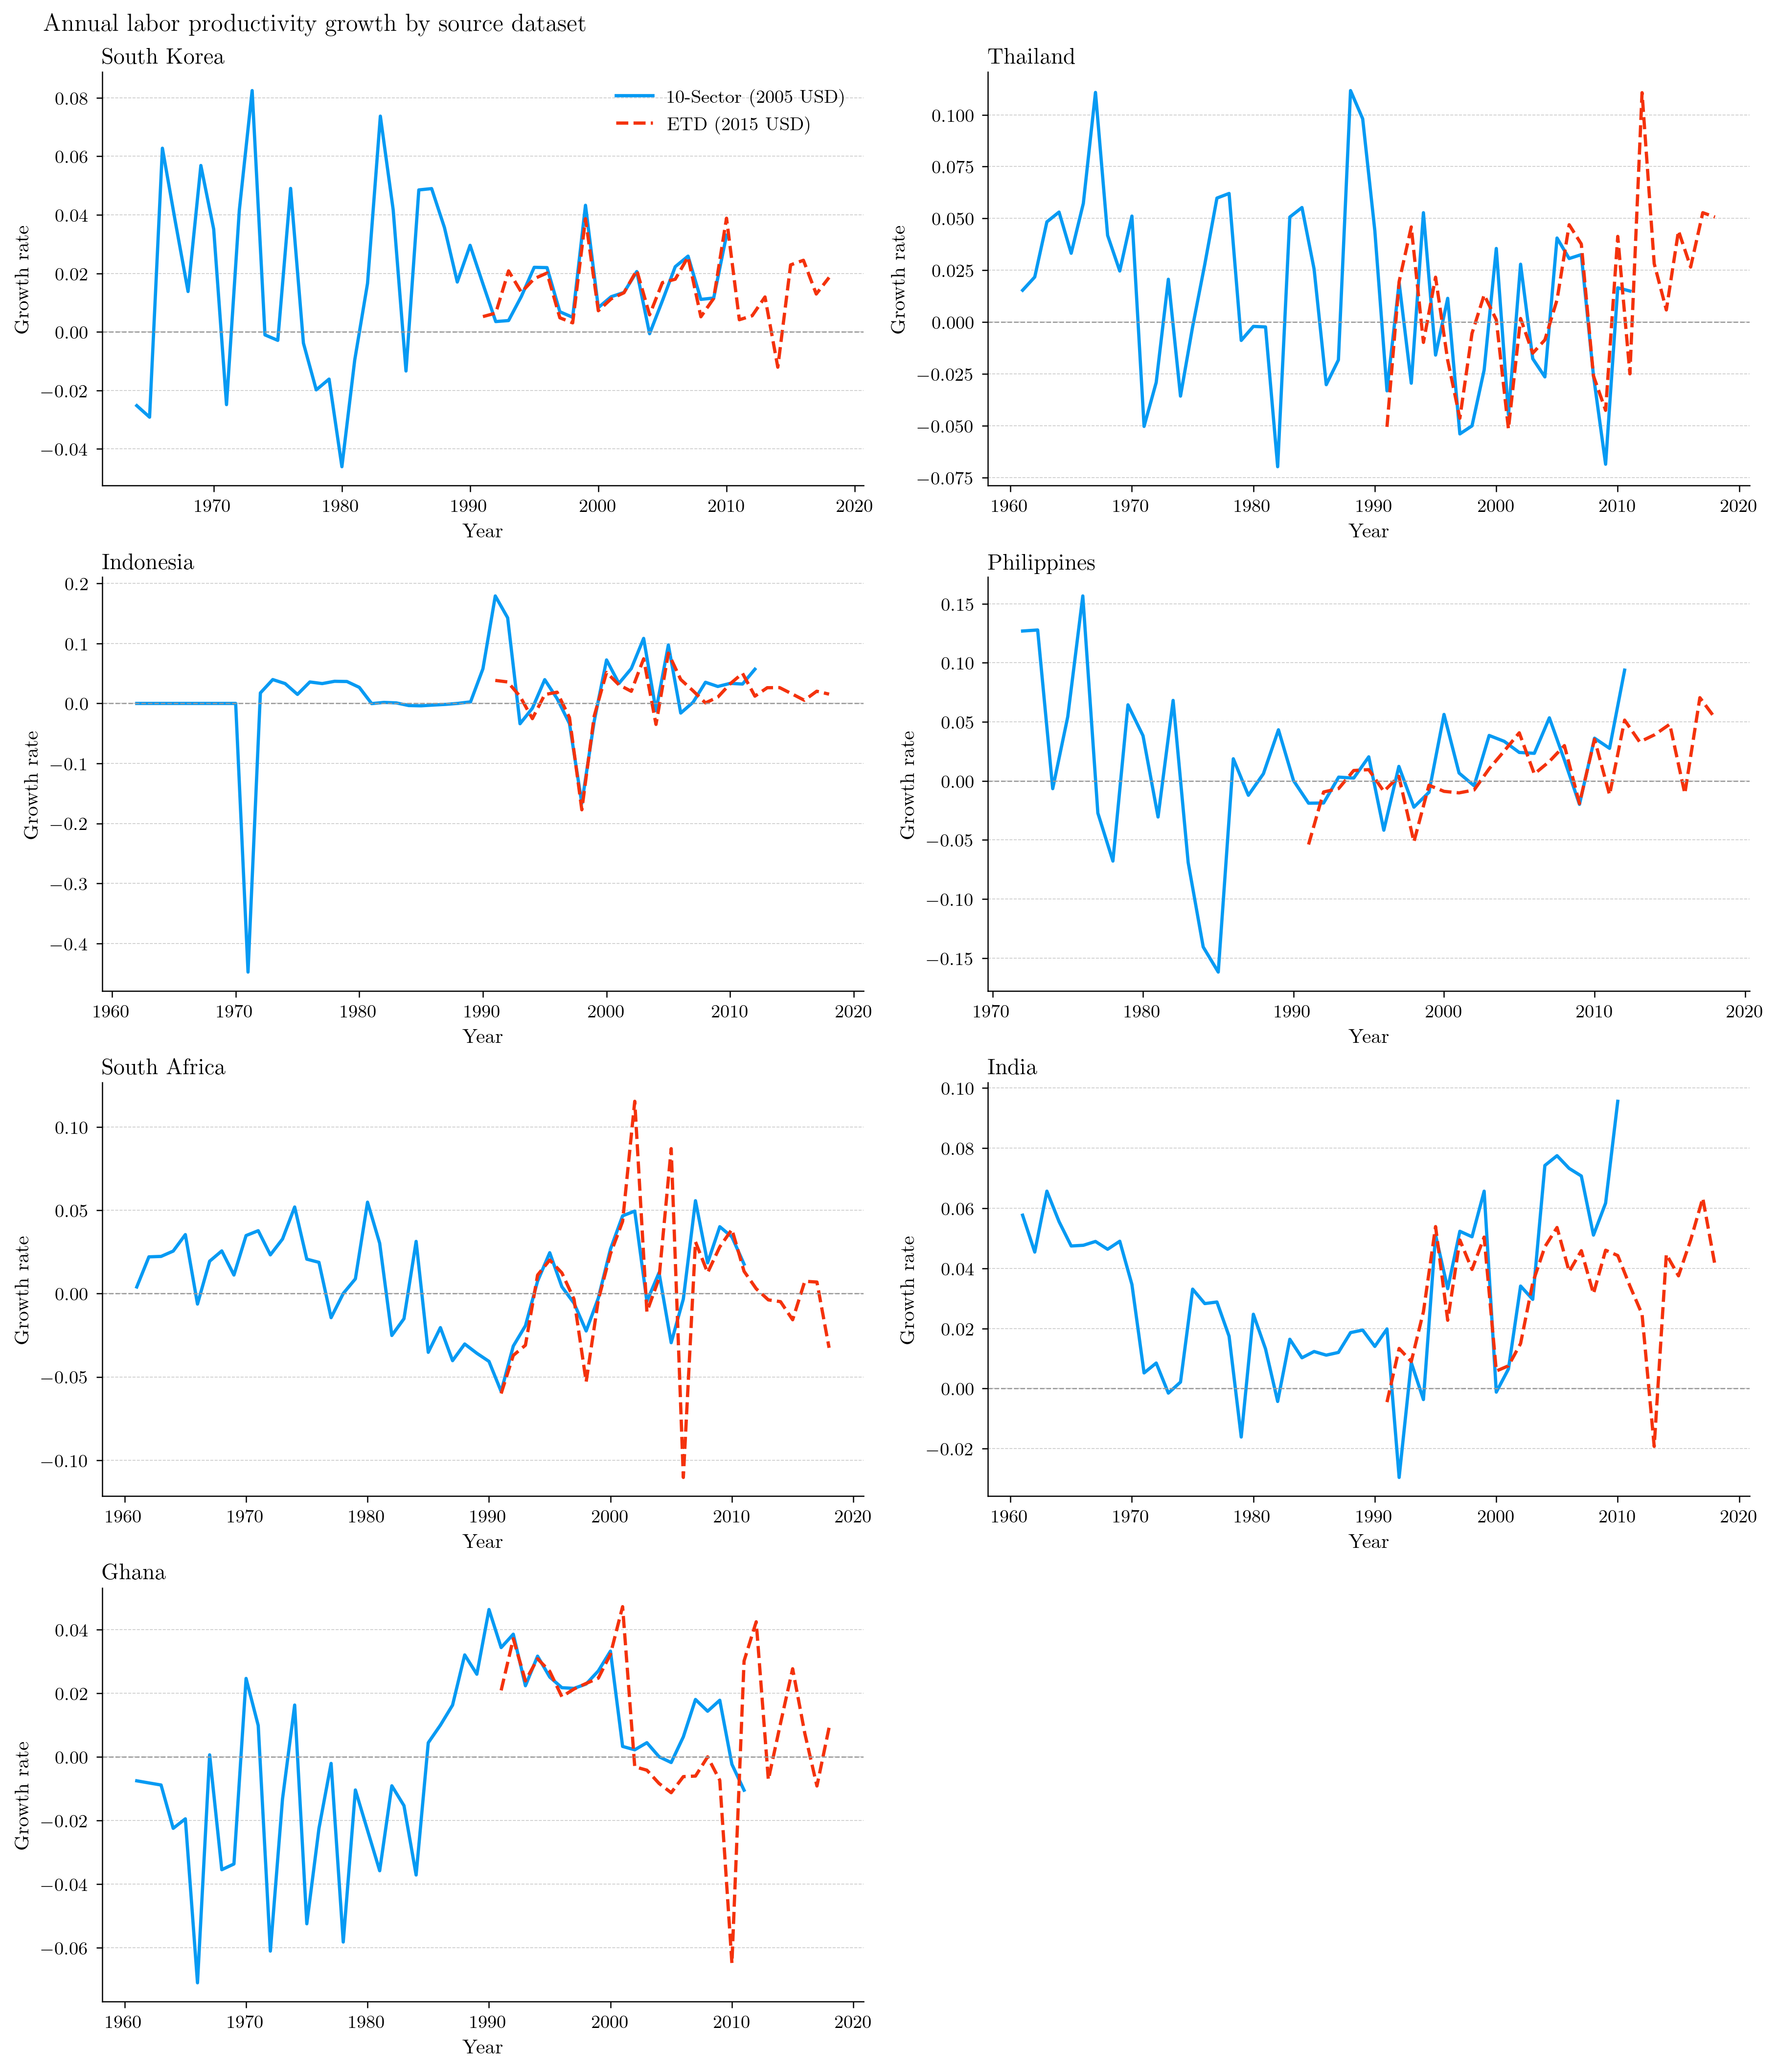

In [8]:
C1, C2 = 'xkcd:azure', 'xkcd:vermillion'  # source 1 (solid) / source 2 (dashed)

fig, axs = plt.subplots(4, 2, figsize=(12, 14), constrained_layout=True)
axs = axs.ravel()

for i, country in enumerate(countries_both):
    df_c1 = df_in[df_in['Country'] == country]
    df_c2 = df_fin[df_fin['cnt'] == country]

    axs[i].plot(df_c1['Year'], df_c1['prod_growth'],
                color=C1, linewidth=1.6, label='10-Sector (2005 USD)')
    axs[i].plot(df_c2['year'], df_c2['prod_growth'],
                color=C2, linewidth=1.6, linestyle='--', label='ETD (2015 USD)')
    axs[i].axhline(0, color='#999999', linewidth=0.6, linestyle='--')

    style_ax(axs[i], xlabel='Year', ylabel='Growth rate',
             title=COUNTRY_NAMES[country])

    if i == 0:
        axs[i].legend(fontsize=9, frameon=False)

# Remove unused panel (7 countries, 4×2 = 8 panels)
fig.delaxes(axs[-1])

fig.suptitle('Annual labor productivity growth by source dataset',
             fontsize=12, x=0.02, ha='left')
fig.savefig('../_results/_figures/IT_prod_growth_comparison.pdf',
            format='pdf', bbox_inches='tight')
plt.show()

## Splice Datasets

**Countries with both datasets (KOR, THA, IDN, PHL, ZAF, IND, GHA)**:
The 10-Sector series (`prod_x`, constant 2005 USD) is extended beyond its last observation
by chaining forward using the ETD growth rate. The chain start year is determined
dynamically as the year immediately following the last non-missing `prod_x` value,
which varies across countries:

| Country | 10-SD last year | Chain from |
|---------|----------------|------------|
| KOR     | 2010           | 2011       |
| THA     | 2011           | 2012       |
| IDN     | 2012           | 2013       |
| PHL     | 2012           | 2013       |
| ZAF     | 2011           | 2012       |
| IND     | 2010           | 2011       |
| GHA     | 2011           | 2012       |

**ETD-only countries (ISR, TUR)**:
`prod_x` is set directly to the ETD productivity level (2015 constant USD). No chaining
is performed. Levels are in a different base year than the other countries, but this does
not affect growth rates or detrended cycles.

In [9]:

# Standardise column names in df_fin before merging
df_fin = df_fin.rename(columns={'cnt': 'Country', 'year': 'Year'})

# Outer merge: keep all country-year observations from both sources
# After merge: _x columns come from df_in (10-Sector), _y columns from df_fin (ETD)
df = pd.merge(df_in, df_fin, on=['Country', 'Year'], how='outer')
df = df.sort_values(by=['Country', 'Year']).reset_index(drop=True)

# ── Chain prod_x forward for countries with both datasets ────────────────────
# prod_x: value added (2005 USD) / employment from the 10-Sector Dataset
# prod_growth_y: ETD annual growth rate used as the chain multiplier
for country in countries_both:
    sub = df[(df['Country'] == country) & df['prod_x'].notna()]
    if sub.empty:
        continue
    last_yr = int(sub['Year'].max())
    for year in range(last_yr + 1, 2019):
        prev_row   = df[(df['Country'] == country) & (df['Year'] == year - 1)]
        curr_row   = df[(df['Country'] == country) & (df['Year'] == year)]
        if prev_row.empty or curr_row.empty:
            continue
        prev_prod  = prev_row['prod_x'].values[0]
        growth     = curr_row['prod_growth_y'].values[0]
        if np.isnan(prev_prod) or np.isnan(growth):
            continue
        df.loc[(df['Country'] == country) & (df['Year'] == year), 'prod_x'] = (
            prev_prod * (1 + growth)
        )

# ── ETD-only countries: use ETD productivity directly ────────────────────────
# NOTE: prod_x for ISR and TUR is in 2015 USD (ETD base year), not 2005 USD.
# This is noted in all tables and does not affect detrended cycles or AR(1) estimates.
for country in countries_etd_only:
    mask = df['Country'] == country
    df.loc[mask, 'prod_x'] = df.loc[mask, 'prod_y']

# Ensure numeric dtype — outer merge + .loc assignments can leave object dtype
df['prod_x'] = pd.to_numeric(df['prod_x'], errors='coerce')

print('prod_x coverage per country (non-NaN years):')
for c in countries:
    sub = df[(df['Country'] == c) & df['prod_x'].notna()]
    print(f'  {c}: {int(sub["Year"].min())}--{int(sub["Year"].max())} ({len(sub)} obs)')


prod_x coverage per country (non-NaN years):
  KOR: 1963--2018 (56 obs)
  THA: 1960--2018 (59 obs)
  IDN: 1961--2018 (49 obs)
  PHL: 1971--2018 (48 obs)
  ZAF: 1960--2018 (59 obs)
  IND: 1960--2018 (59 obs)
  GHA: 1960--2018 (59 obs)
  ISR: 1990--2018 (29 obs)
  TUR: 1990--2018 (29 obs)


### Labor productivity levels

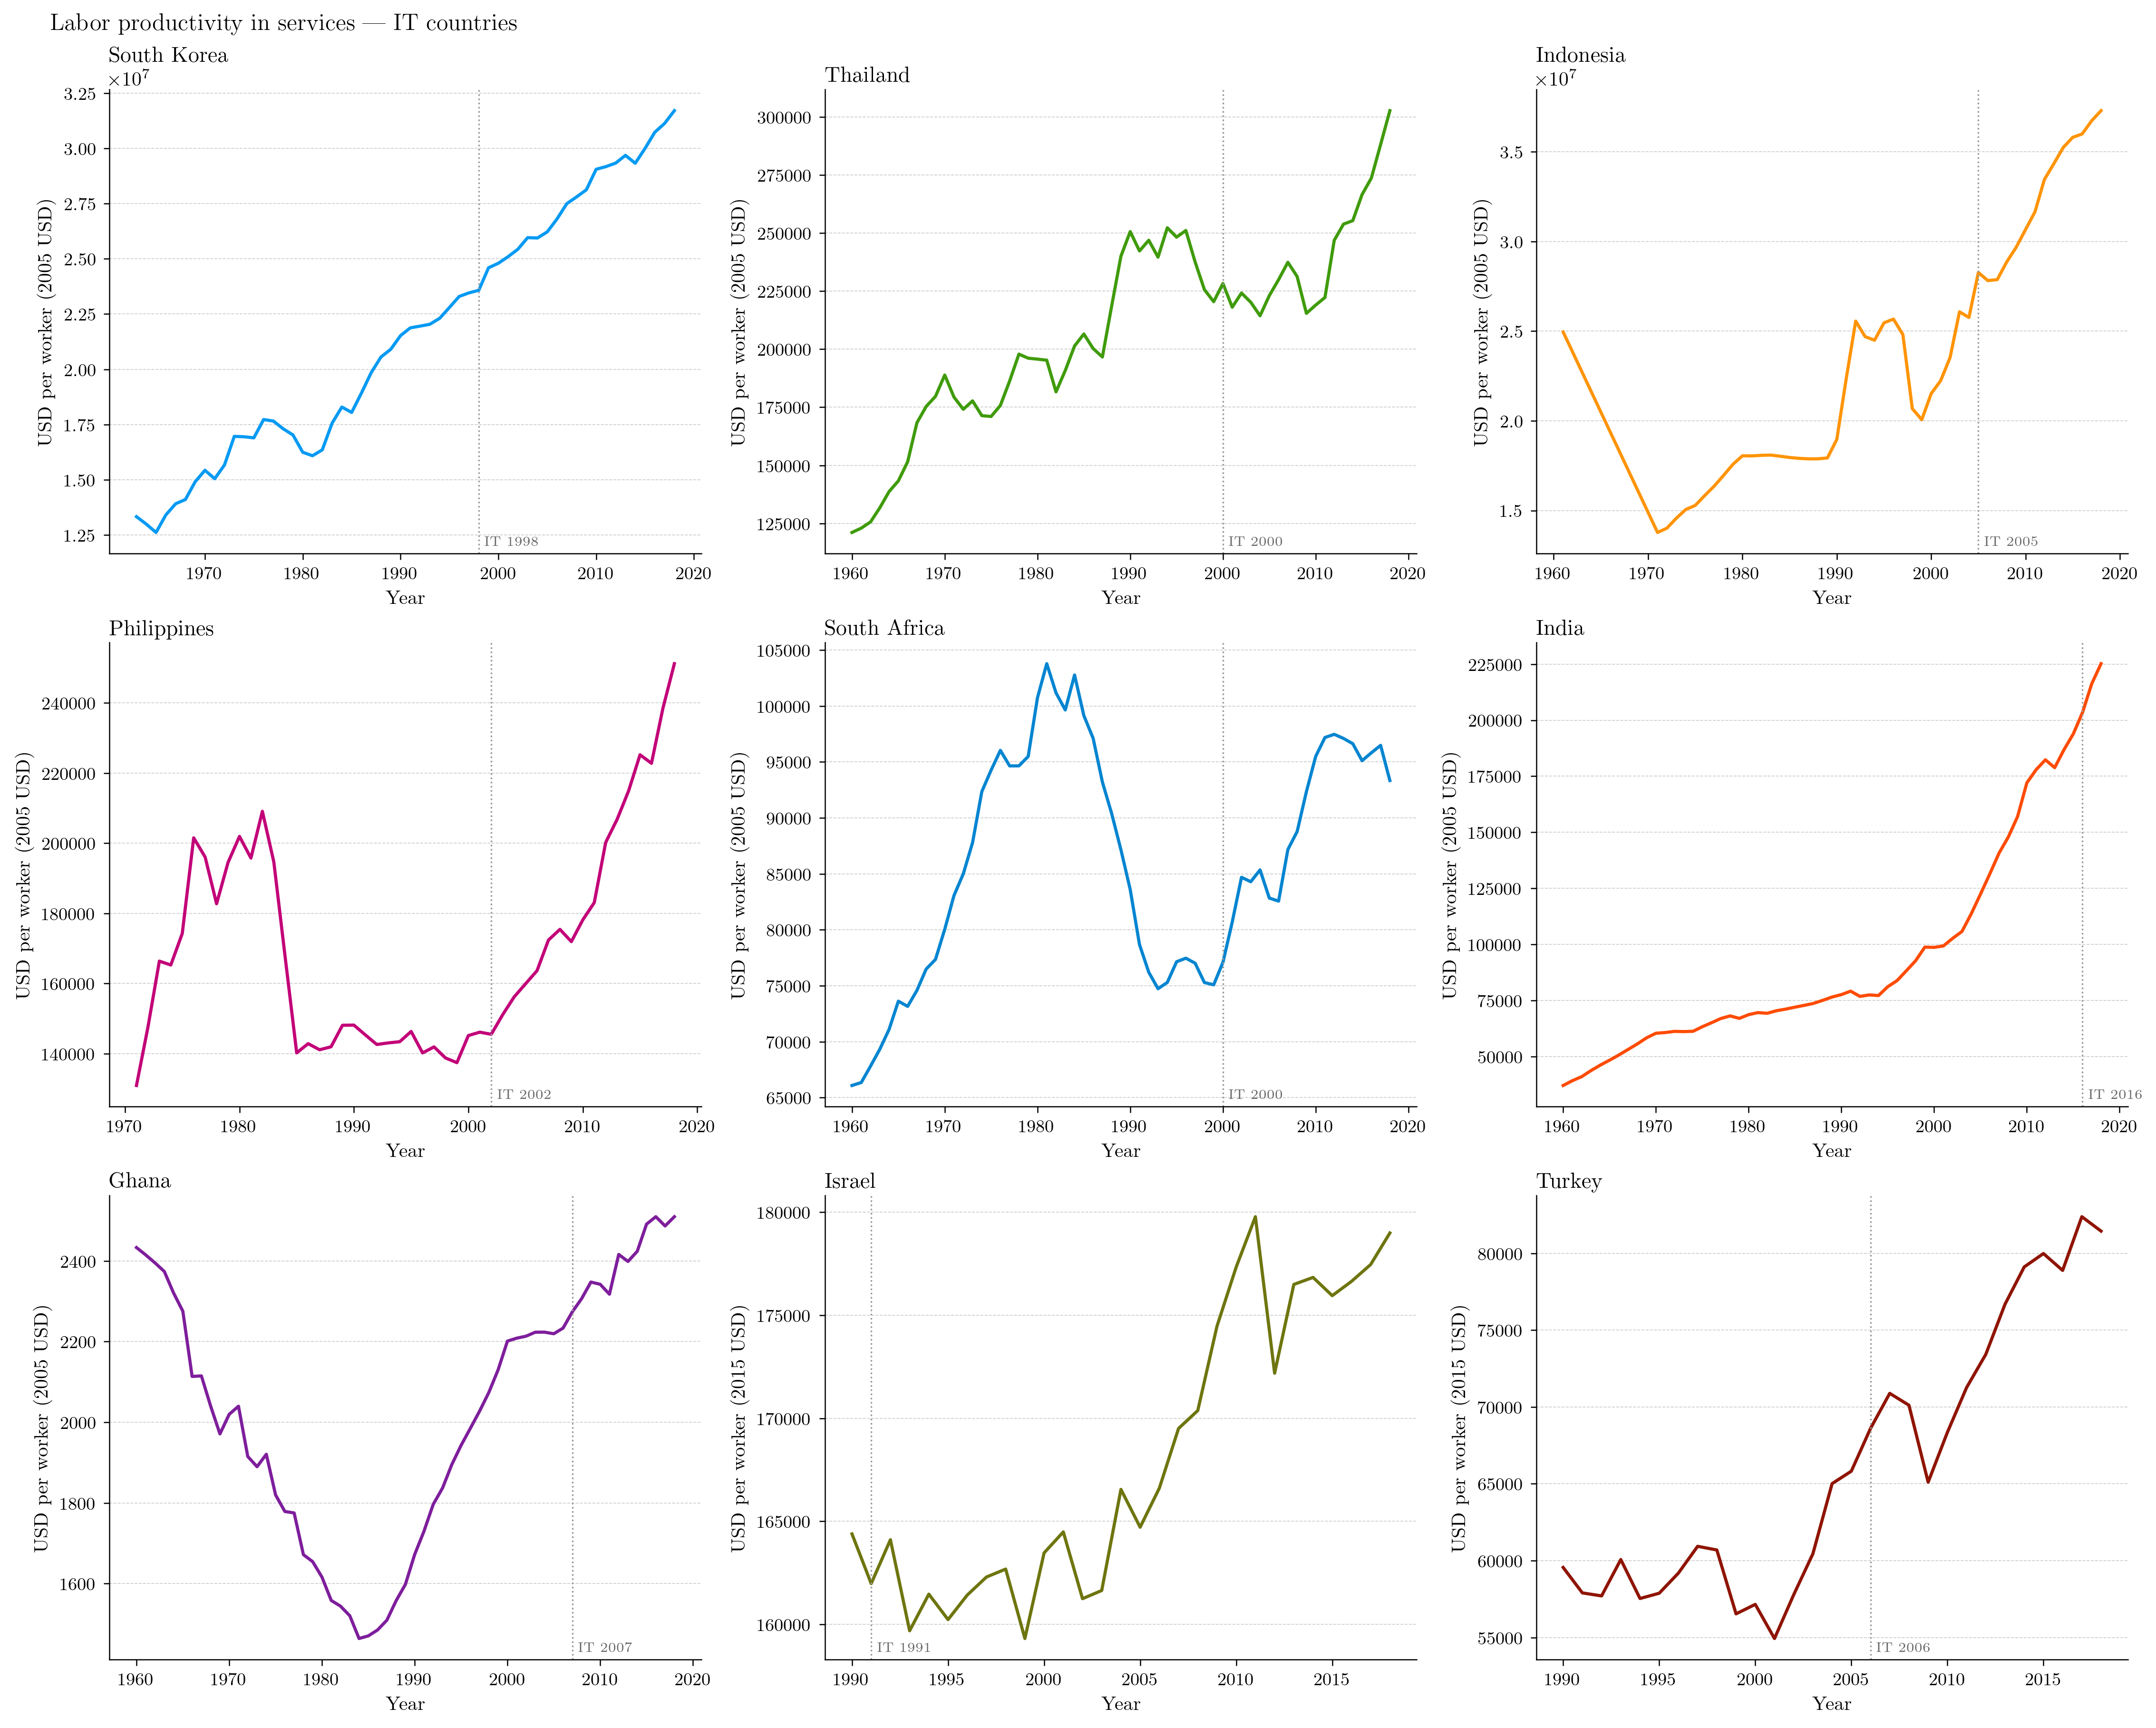

In [10]:

fig, axs = plt.subplots(3, 3, figsize=(15, 12), constrained_layout=True)
axs = axs.ravel()

for i, country in enumerate(countries):
    df_c = df[df['Country'] == country].dropna(subset=['prod_x'])
    axs[i].plot(df_c['Year'], df_c['prod_x'],
                color=COLORS[country], linewidth=1.6)

    # IT adoption year: vertical dotted line + text in axis-relative coordinates
    it_yr = IT_DATES[country]
    axs[i].axvline(it_yr, color='#999999', linewidth=0.8, linestyle=':')
    # Use ax.transData + blended transform so x is in data coords, y in axis fraction
    axs[i].annotate(
        f'IT {it_yr}',
        xy=(it_yr, 0), xycoords=('data', 'axes fraction'),
        xytext=(3, 4), textcoords='offset points',
        fontsize=7, color='#666666'
    )

    unit_note = '2015 USD' if country in countries_etd_only else '2005 USD'
    style_ax(axs[i], xlabel='Year',
             ylabel=f'USD per worker ({unit_note})',
             title=COUNTRY_NAMES[country])

fig.suptitle('Labor productivity in services --- IT countries',
             fontsize=12, x=0.02, ha='left')
fig.savefig('../_results/_figures/IT_productivity.pdf',
            format='pdf', bbox_inches='tight')
plt.show()


## Detrending

### Hamilton filter

The Hamilton (2018) regression filter extracts the cyclical component by projecting
log-productivity at time $t$ on its own lagged values at $t-h, \ldots, t-h-p+1$:

$$
a_{i,t} = \alpha_0 + \sum_{j=0}^{p-1} \alpha_{j+1}\, a_{i,t-h-j} + z_{i,t}
$$

The residual $z_{i,t}$ is the cyclical component. Following Hamilton's recommendations for
annual data, we use $h=2$ and $p=4$, which requires the first $h+p-1=5$ observations as
regressors. The HP filter ($\lambda=100$) is computed for comparison.

**Sample-length note**: Countries with only ETD data (ISR, TUR) have 29 observations
(1990–2018); after the 5-observation burn-in the cycle covers 1995–2018 (24 obs),
yielding 23 AR(1) pairs. This is noted in the estimation table.

In [11]:
def hamilton_filter(log_y, h=2, p=4):
    """
    Hamilton (2018) regression filter.

    Regresses log_y[t] on log_y[t-h], log_y[t-h-1], ..., log_y[t-h-p+1]
    via OLS. The residual is the cyclical component.

    Advantages over HP filter:
      - No endpoint bias.
      - No spurious cycles from the two-sided smoother.
      - Standard OLS inference applies.
    Cost: loses first h+p-1 observations at the start.

    Parameters
    ----------
    log_y : array-like  Log-productivity series (length T).
    h     : int         Forecast horizon (Hamilton recommends h=2 for annual data).
    p     : int         Number of lags   (Hamilton recommends p=4).

    Returns
    -------
    cycle : np.ndarray, length T — NaN for the first h+p-1 observations.
    fit   : OLS RegressionResultsWrapper.
    """
    y  = np.asarray(log_y, dtype=float)
    T  = len(y)
    t0 = h + p - 1
    Y  = y[t0:]
    X  = np.column_stack([y[(t0 - h - j):(T - h - j)] for j in range(p)])
    X  = sm.add_constant(X)
    fit = sm.OLS(Y, X).fit()
    cycle = np.full(T, np.nan)
    cycle[t0:] = fit.resid
    return cycle, fit


# Drop observations with missing productivity before filtering
df = df.dropna(subset=['prod_x'])

H, P, HP_LAMBDA = 2, 4, 100

for country in countries:
    df_c = df[df['Country'] == country].copy()

    # Hamilton filter
    cycle_h, _ = hamilton_filter(np.log(df_c['prod_x']), h=H, p=P)
    df.loc[df['Country'] == country, 'prod_x_detrended'] = cycle_h

    # HP filter
    cycle_hp, _ = hp_filter(np.log(df_c['prod_x']), lamb=HP_LAMBDA)
    df.loc[df['Country'] == country, 'prod_x_detrended_hp'] = cycle_hp.values

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarnin

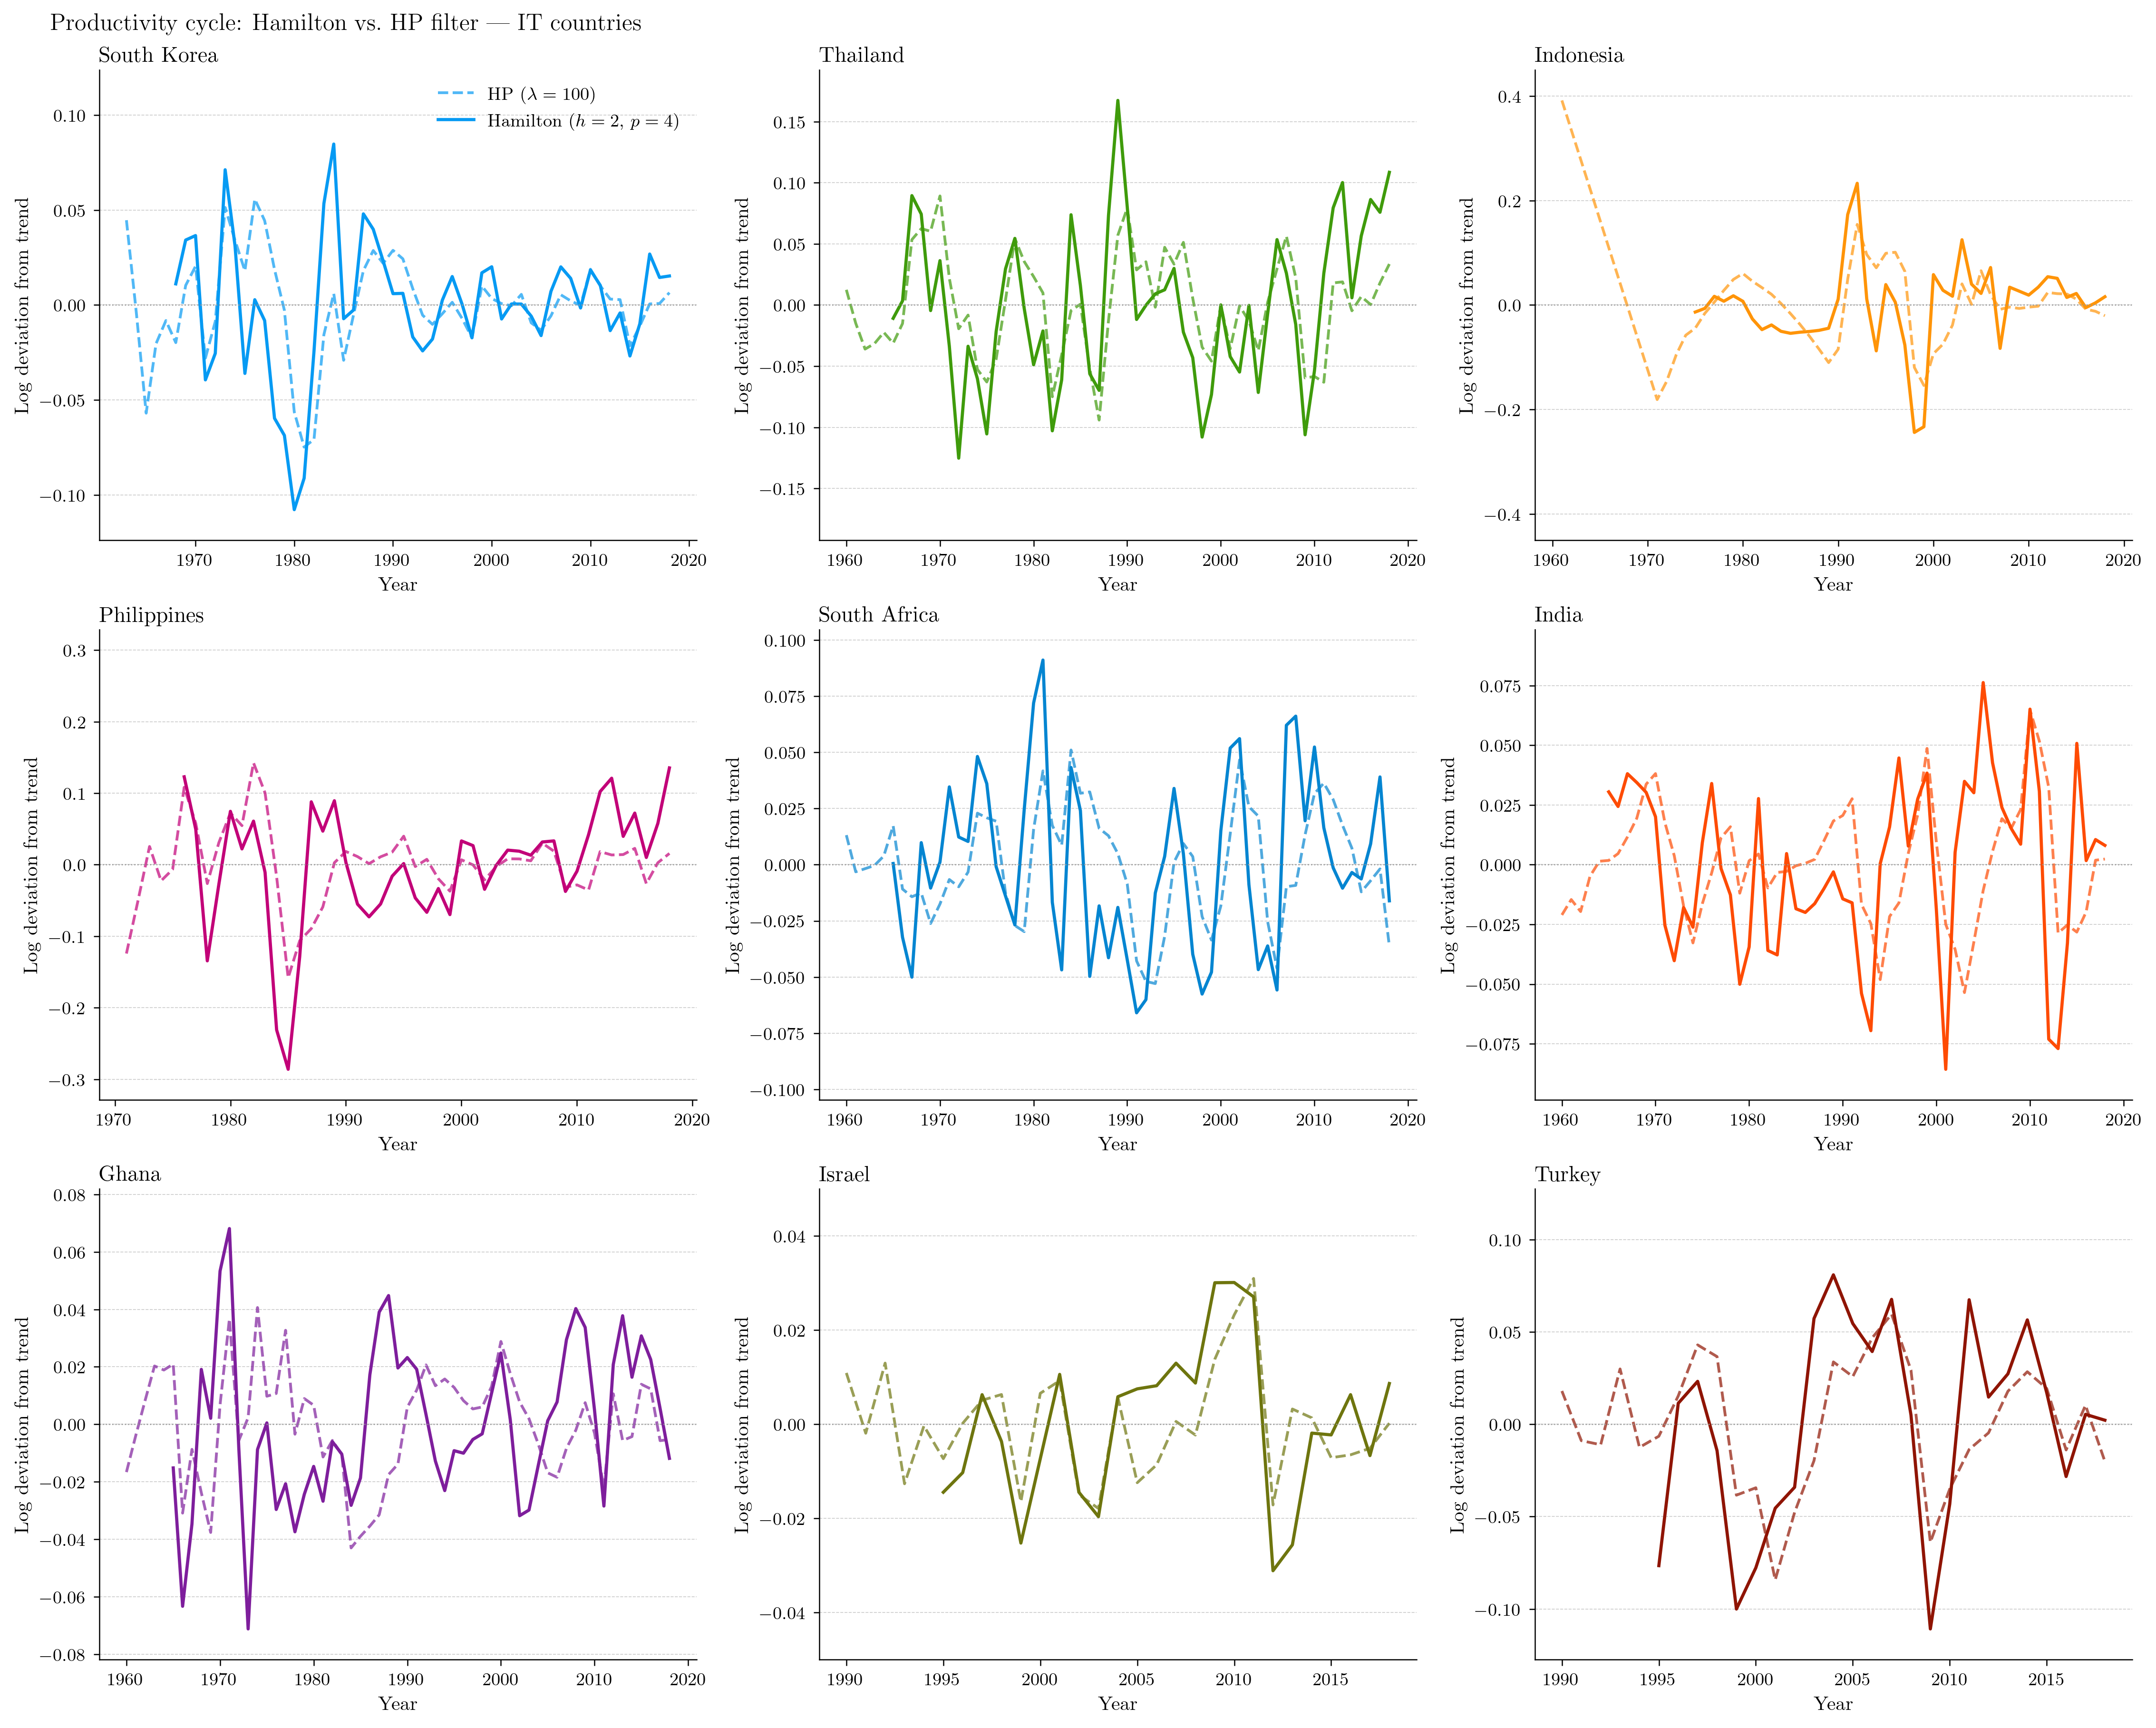

In [12]:
fig, axs = plt.subplots(3, 3, figsize=(15, 12), constrained_layout=True)
axs = axs.ravel()

for i, country in enumerate(countries):
    df_c = df[df['Country'] == country]

    axs[i].plot(df_c['Year'], df_c['prod_x_detrended_hp'],
                color=COLORS[country], linewidth=1.4, linestyle='--',
                alpha=0.7, label=f'HP ($\\lambda={HP_LAMBDA}$)')
    axs[i].plot(df_c['Year'], df_c['prod_x_detrended'],
                color=COLORS[country], linewidth=1.6,
                label=f'Hamilton ($h={H}$, $p={P}$)')
    axs[i].axhline(0, color='#999999', linewidth=0.6, linestyle=':')

    # Dynamic symmetric y-limits with 15% padding
    vals = pd.concat([df_c['prod_x_detrended'].dropna(),
                      df_c['prod_x_detrended_hp'].dropna()])
    if len(vals):
        abs_max = max(abs(vals.min()), abs(vals.max()))
        ylim = max(abs_max * 1.15, 0.05)
        axs[i].set_ylim(-ylim, ylim)

    style_ax(axs[i], xlabel='Year',
             ylabel='Log deviation from trend',
             title=COUNTRY_NAMES[country])

    if i == 0:
        axs[i].legend(fontsize=9, frameon=False)

fig.suptitle('Productivity cycle: Hamilton vs.\ HP filter --- IT countries',
             fontsize=12, x=0.02, ha='left')
fig.savefig('../_results/_figures/IT_productivity_detrended.pdf',
            format='pdf', bbox_inches='tight')
plt.show()

## AR(1) Estimation of the Productivity Process

The cyclical component $z_{i,t}$ is modelled as:
$$
z_{i,t} = \rho_i\, z_{i,t-1} + \varepsilon_{i,t}, \qquad
\varepsilon_{i,t} \sim \mathcal{N}(0,\, \sigma^2_{\varepsilon,i})
$$

Per-country parameters are estimated by Conditional Maximum Likelihood via
`statsmodels.tsa.ar_model.AutoReg`. A pooled estimate (HC1-robust SEs) is also reported.

**Footnote conventions in the output table**:
- $^\dagger$: ETD-only country (ISR, TUR) — levels in 2015 USD; shorter sample (1990–2018).
- $N$: number of AR(1) regression pairs (= effective sample length minus 1 lag).

In [13]:

# ── Table formatting helpers ──────────────────────────────────────────────────
W   = {'country': 14, 'sample': 13, 'n': 4, 'rho': 8, 'se': 8, 'sigma': 10, 'var': 10}
SEP = '  '

def fmt_header():
    h  = f'  {"Country":<{W["country"]}} {"Sample":<{W["sample"]}} {"N":>{W["n"]}}'
    h += f'{SEP}{"rho":>{W["rho"]}} {"se(rho)":>{W["se"]}}'
    h += f'{SEP}{"sigma_eps":>{W["sigma"]}} {"var_eps":>{W["var"]}}'
    return h

def fmt_row(label, sample, n, rho, se_rho, sigma, var):
    r  = f'  {label:<{W["country"]}} {sample:<{W["sample"]}} {n:>{W["n"]}}'
    r += f'{SEP}{rho:>{W["rho"]}.4f} {se_rho:>{W["se"]}.4f}'
    r += f'{SEP}{sigma:>{W["sigma"]}.6f} {var:>{W["var"]}.6f}'
    return r

header  = fmt_header()
divider = '  ' + '-' * (len(header) - 2)

# ── Per-country AR(1) — Hamilton filter ───────────────────────────────────────
ar_results_hamilton = {}
ar_results_hp       = {}
model_fits_h        = {}
model_fits_hp       = {}
pooled_pairs        = []
pooled_pairs_hp     = []

print('Hamilton filter (h=2, p=4):')
print(header)
print(divider)

for country in countries:
    df_c = df[df['Country'] == country].dropna(subset=['prod_x_detrended']).copy()
    yr_min = int(df_c['Year'].min())
    yr_max = int(df_c['Year'].max())
    # Set DatetimeIndex without freq= to avoid validation errors on non-contiguous data
    df_c.index = pd.to_datetime(df_c['Year'], format='%Y')

    fit = AutoReg(df_c['prod_x_detrended'], lags=1).fit()
    model_fits_h[country] = fit

    lag_param = [pk for pk in fit.params.index if pk != 'const'][0]
    rho       = fit.params[lag_param]
    se_rho    = fit.bse[lag_param]
    sigma_eps = np.sqrt(fit.sigma2)
    var_eps   = fit.sigma2
    n_obs     = fit.nobs

    ar_results_hamilton[country] = dict(
        rho=rho, se_rho=se_rho, sigma_eps=sigma_eps, var_eps=var_eps,
        yr_min=yr_min, yr_max=yr_max, n_obs=n_obs
    )

    dagger = u'\u2020' if country in countries_etd_only else ''
    label  = COUNTRY_NAMES[country] + dagger
    print(fmt_row(label, f'{yr_min}-{yr_max}', n_obs, rho, se_rho, sigma_eps, var_eps))

    y = df_c['prod_x_detrended'].values
    pooled_pairs.append(pd.DataFrame({'y_t': y[1:], 'y_lag': y[:-1]}))

# Pooled OLS (HC1-robust, within-country lags only)
df_pairs   = pd.concat(pooled_pairs, ignore_index=True)
X_pool     = sm.add_constant(df_pairs['y_lag'])
pooled_ols = sm.OLS(df_pairs['y_t'], X_pool).fit(cov_type='HC1')
n_pairs    = len(df_pairs)
rho_pool   = pooled_ols.params['y_lag']
se_pool    = pooled_ols.bse['y_lag']
var_pool   = np.sum(pooled_ols.resid ** 2) / n_pairs
sigma_pool = np.sqrt(var_pool)
yr_min_pool = min(v['yr_min'] for v in ar_results_hamilton.values())
yr_max_pool = max(v['yr_max'] for v in ar_results_hamilton.values())

ar_results_hamilton['POOLED'] = dict(
    rho=rho_pool, se_rho=se_pool, sigma_eps=sigma_pool, var_eps=var_pool,
    yr_min=yr_min_pool, yr_max=yr_max_pool, n_obs=n_pairs
)

print(divider)
print(fmt_row('POOLED', f'{yr_min_pool}-{yr_max_pool}', n_pairs,
              rho_pool, se_pool, sigma_pool, var_pool))
print(u'\u2020 ETD-only (ISR, TUR): 2015 USD levels; sample 1990-2018.')

# ── Per-country AR(1) — HP filter ────────────────────────────────────────────
print('\nHP filter (lambda=100):')
print(header)
print(divider)

for country in countries:
    df_c = df[df['Country'] == country].dropna(subset=['prod_x_detrended_hp']).copy()
    yr_min = int(df_c['Year'].min())
    yr_max = int(df_c['Year'].max())
    df_c.index = pd.to_datetime(df_c['Year'], format='%Y')

    fit_hp = AutoReg(df_c['prod_x_detrended_hp'], lags=1).fit()
    model_fits_hp[country] = fit_hp

    lag_param = [pk for pk in fit_hp.params.index if pk != 'const'][0]
    rho_hp    = fit_hp.params[lag_param]
    se_hp     = fit_hp.bse[lag_param]
    sigma_hp  = np.sqrt(fit_hp.sigma2)
    var_hp    = fit_hp.sigma2
    n_obs_hp  = fit_hp.nobs

    ar_results_hp[country] = dict(
        rho=rho_hp, se_rho=se_hp, sigma_eps=sigma_hp, var_eps=var_hp,
        yr_min=yr_min, yr_max=yr_max, n_obs=n_obs_hp
    )

    dagger = u'\u2020' if country in countries_etd_only else ''
    label  = COUNTRY_NAMES[country] + dagger
    print(fmt_row(label, f'{yr_min}-{yr_max}', n_obs_hp, rho_hp, se_hp, sigma_hp, var_hp))

    y = df_c['prod_x_detrended_hp'].values
    pooled_pairs_hp.append(pd.DataFrame({'y_t': y[1:], 'y_lag': y[:-1]}))

df_pairs_hp   = pd.concat(pooled_pairs_hp, ignore_index=True)
X_pool_hp     = sm.add_constant(df_pairs_hp['y_lag'])
pooled_hp     = sm.OLS(df_pairs_hp['y_t'], X_pool_hp).fit(cov_type='HC1')
n_pairs_hp    = len(df_pairs_hp)
rho_pool_hp   = pooled_hp.params['y_lag']
se_pool_hp    = pooled_hp.bse['y_lag']
var_pool_hp   = np.sum(pooled_hp.resid ** 2) / n_pairs_hp
sigma_pool_hp = np.sqrt(var_pool_hp)
yr_min_hp     = min(v['yr_min'] for v in ar_results_hp.values())
yr_max_hp     = max(v['yr_max'] for v in ar_results_hp.values())

ar_results_hp['POOLED'] = dict(
    rho=rho_pool_hp, se_rho=se_pool_hp, sigma_eps=sigma_pool_hp, var_eps=var_pool_hp,
    yr_min=yr_min_hp, yr_max=yr_max_hp, n_obs=n_pairs_hp
)

print(divider)
print(fmt_row('POOLED', f'{yr_min_hp}-{yr_max_hp}', n_pairs_hp,
              rho_pool_hp, se_pool_hp, sigma_pool_hp, var_pool_hp))
print(u'\u2020 ETD-only (ISR, TUR): 2015 USD levels; sample 1990-2018.')


Hamilton filter (h=2, p=4):
  Country        Sample           N       rho  se(rho)   sigma_eps    var_eps
  ---------------------------------------------------------------------------
  South Korea    1968-2018       50    0.5161   0.1213    0.030040   0.000902
  Thailand       1965-2018       53    0.5259   0.1214    0.054918   0.003016
  Indonesia      1975-2018       43    0.4693   0.1347    0.070942   0.005033
  Philippines    1976-2018       42    0.5412   0.1308    0.069738   0.004863
  South Africa   1965-2018       53    0.4475   0.1231    0.034388   0.001183
  India          1965-2018       53    0.4540   0.1214    0.032064   0.001028
  Ghana          1965-2018       53    0.5365   0.1157    0.023445   0.000550
  Israel†        1995-2018       23    0.3868   0.1898    0.015219   0.000232
  Turkey†        1995-2018       23    0.4381   0.1769    0.046443   0.002157
  ---------------------------------------------------------------------------
  POOLED         1965-2018      393 

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequenc

### LaTeX table

In [14]:

latex_lines = [
    r'\begin{table}[htbp]',
    r'  \centering',
    r'  \caption{AR(1) Estimates of Log-Productivity Cycles --- Inflation-Targeting Countries}',
    r'  \label{tab:ar1_productivity_it}',
    r'  \begin{tabular}{llrcccc}',
    r'    \toprule',
    r'    Country & Filter & $N$ & $\hat{\rho}$ & se$(\hat{\rho})$ & $\hat{\sigma}_{\varepsilon}$ & $\hat{\sigma}^2_{\varepsilon}$ \\',
    r'    \midrule',
]

for key in countries + ['POOLED']:
    rH  = ar_results_hamilton[key]
    rHP = ar_results_hp[key]

    if key == 'POOLED':
        latex_lines.append(r'    \midrule')
        label_tex = r'\textit{Pooled}'
    else:
        name      = COUNTRY_NAMES[key]
        dagger    = r'$^{\dagger}$' if key in countries_etd_only else ''
        label_tex = name + dagger

    latex_lines.append(
        f"    {label_tex} & Hamilton"
        f" & {rH['n_obs']} & {rH['rho']:.4f} & ({rH['se_rho']:.4f})"
        f" & {rH['sigma_eps']:.6f} & {rH['var_eps']:.6f} \\\\"
    )
    latex_lines.append(
        f"    & HP filter"
        f" & {rHP['n_obs']} & {rHP['rho']:.4f} & ({rHP['se_rho']:.4f})"
        f" & {rHP['sigma_eps']:.6f} & {rHP['var_eps']:.6f} \\\\[3pt]"
    )

latex_lines += [
    r'    \bottomrule',
    r'  \end{tabular}',
    r'  \\[4pt]',
    r'  \footnotesize\textit{Notes:} Standard errors in parentheses. '
    r'$N$ = regression pairs. '
    r'Hamilton filter loses first 5 obs per country ($h+p-1=5$). '
    r'$\hat{\sigma}_{\varepsilon}$ and $\hat{\sigma}^2_{\varepsilon}$: MLE convention (RSS$/N$). '
    r'Pooled SEs are HC1-robust. '
    r'$^{\dagger}$Israel and Turkey use ETD only (1990--2018, 2015 constant USD); '
    r'all other countries splice the 10-Sector Dataset with the ETD (2005 constant USD).',
    r'\end{table}',
]

latex_str = '\n'.join(latex_lines)
print(latex_str)

with open('../_results/_tables/ar1_productivity_IT.tex', 'w') as f_tex:
    f_tex.write(latex_str + '\n')
print('\nLaTeX table saved to ../_results/_tables/ar1_productivity_IT.tex')


\begin{table}[htbp]
  \centering
  \caption{AR(1) Estimates of Log-Productivity Cycles --- Inflation-Targeting Countries}
  \label{tab:ar1_productivity_it}
  \begin{tabular}{llrcccc}
    \toprule
    Country & Filter & $N$ & $\hat{\rho}$ & se$(\hat{\rho})$ & $\hat{\sigma}_{\varepsilon}$ & $\hat{\sigma}^2_{\varepsilon}$ \\
    \midrule
    South Korea & Hamilton & 50 & 0.5161 & (0.1213) & 0.030040 & 0.000902 \\
    & HP filter & 55 & 0.5702 & (0.1063) & 0.020475 & 0.000419 \\[3pt]
    Thailand & Hamilton & 53 & 0.5259 & (0.1214) & 0.054918 & 0.003016 \\
    & HP filter & 58 & 0.5766 & (0.1081) & 0.033593 & 0.001129 \\[3pt]
    Indonesia & Hamilton & 43 & 0.4693 & (0.1347) & 0.070942 & 0.005033 \\
    & HP filter & 48 & 0.2538 & (0.1057) & 0.066105 & 0.004370 \\[3pt]
    Philippines & Hamilton & 42 & 0.5412 & (0.1308) & 0.069738 & 0.004863 \\
    & HP filter & 47 & 0.5346 & (0.1128) & 0.041252 & 0.001702 \\[3pt]
    South Africa & Hamilton & 53 & 0.4475 & (0.1231) & 0.034388 & 0.001183 \

### Residual diagnostics — pooled AR(1)

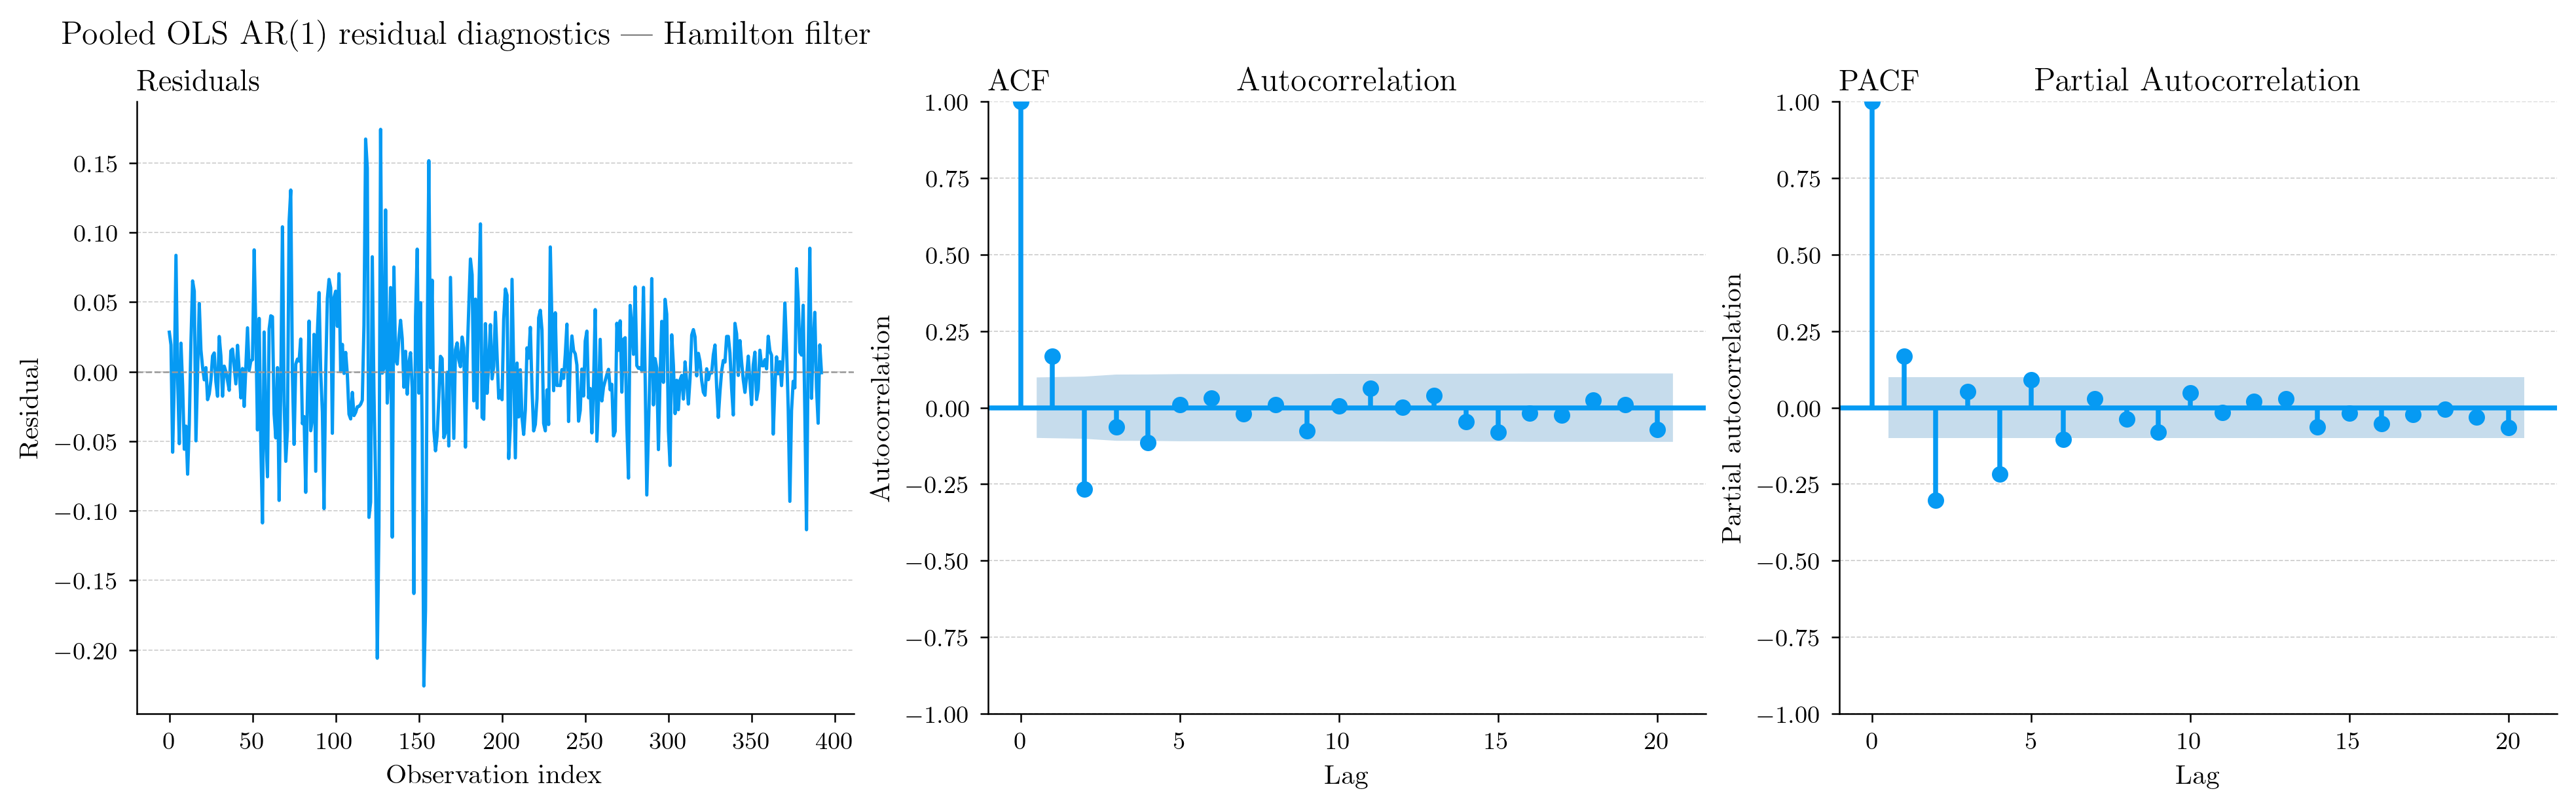

In [15]:
residuals = pooled_ols.resid

fig, axs = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)

axs[0].plot(residuals.values, color='xkcd:azure', linewidth=1.2)
axs[0].axhline(0, color='#999999', linewidth=0.6, linestyle='--')
style_ax(axs[0], xlabel='Observation index',
         ylabel='Residual', title='Residuals')

plot_acf(residuals, ax=axs[1], lags=20, alpha=0.05,
         color='xkcd:azure', vlines_kwargs={'colors': 'xkcd:azure'})
style_ax(axs[1], xlabel='Lag', ylabel='Autocorrelation', title='ACF')

plot_pacf(residuals, ax=axs[2], lags=20, alpha=0.05, method='ywm',
          color='xkcd:azure', vlines_kwargs={'colors': 'xkcd:azure'})
style_ax(axs[2], xlabel='Lag', ylabel='Partial autocorrelation', title='PACF')

fig.suptitle('Pooled OLS AR(1) residual diagnostics --- Hamilton filter',
             fontsize=12, x=0.02, ha='left')
fig.savefig('../_results/_figures/IT_ar1_diagnostics.pdf',
            format='pdf', bbox_inches='tight')
plt.show()

## Estimation of Productivity Process Parameters

We model log labor productivity in the services sector as the sum of a predictable trend
and a cyclical component. The trend is removed using the Hamilton (2018) regression filter.

Let $a_{i,t} = \log(\text{VA}_{i,t} / L_{i,t})$ denote log labor productivity for country
$i$ in year $t$. The Hamilton filter extracts the cycle as the OLS residual of:
$$
a_{i,t} = \alpha_0 + \alpha_1\, a_{i,t-h} + \alpha_2\, a_{i,t-h-1}
         + \alpha_3\, a_{i,t-h-2} + \alpha_4\, a_{i,t-h-3} + z_{i,t},
$$
with $h=2$ and $p=4$ (Hamilton's recommendations for annual data). The first $h+p-1=5$
observations serve as regressors and are unavailable for the cycle.

The cyclical component $z_{i,t}$ is assumed to follow:
$$
z_{i,t} = \rho_i\, z_{i,t-1} + \varepsilon_{i,t},
\qquad \varepsilon_{i,t} \sim \mathcal{N}(0,\, \sigma^2_{\varepsilon,i}).
$$

Per-country $\hat{\rho}_i$ and $\hat{\sigma}_{\varepsilon,i}$ are estimated by Conditional
Maximum Likelihood. A pooled estimate is obtained by stacking within-country lag pairs and
running OLS with HC1-robust standard errors (to account for cross-country heteroskedasticity).

> **Reference:** Hamilton, J.D. (2018). Why You Should Never Use the Hodrick--Prescott
> Filter. *Review of Economics and Statistics*, 100(5), 831--843.

## Export Panel Data

Export the panel with productivity levels and both detrended series for use in simulation
notebooks.

In [16]:
panel = df[['Country', 'Year', 'prod_x', 'prod_x_detrended', 'prod_x_detrended_hp']].copy()
panel['etd_only'] = panel['Country'].isin(countries_etd_only)
panel.to_excel('../_results/_data/prod_data_IT.xlsx', index=False)
print('Panel saved to ../_results/_data/prod_data_IT.xlsx')
print(f'Shape: {panel.shape}')
print(panel.groupby('Country')[['Year']].agg(['min', 'max', 'count']))

Panel saved to ../_results/_data/prod_data_IT.xlsx
Shape: (447, 6)
         Year            
          min   max count
Country                  
GHA      1960  2018    59
IDN      1961  2018    49
IND      1960  2018    59
ISR      1990  2018    29
KOR      1963  2018    56
PHL      1971  2018    48
THA      1960  2018    59
TUR      1990  2018    29
ZAF      1960  2018    59


## Export AR(1) Parameters

Export pooled AR(1) estimates for the **IT-EMBI countries**
(`IDN`, `PHL`, `ZAF`, `IND`, `TUR`, `HUN`) — both Hamilton and HP filter —
for use in `Parameters.ipynb`.

In [17]:
import json

# ── Country groups (ISO3) ─────────────────────────────────────────────────────
LAC5_ISO3    = ['BRA', 'CHL', 'COL', 'MEX', 'PER']
IT_EMBI_ISO3 = ['IDN', 'PHL', 'ZAF', 'IND', 'TUR', 'HUN']
IT_ISO3      = LAC5_ISO3 + IT_EMBI_ISO3   # 11 countries

# ── Load LAC-5 productivity data ─────────────────────────────────────────────
prod_lac5 = pd.read_excel('../_results/_data/prod_data.xlsx')   # BRA CHL COL MEX PER

# Combine IT non-LAC5 (from df) with LAC-5 into one panel
# df has IT non-LAC5 countries; prod_lac5 has LAC-5
df_all = pd.concat([
    df[['Country', 'Year', 'prod_x_detrended', 'prod_x_detrended_hp']],
    prod_lac5[['Country', 'Year', 'prod_x_detrended', 'prod_x_detrended_hp']],
], ignore_index=True)

# ── Pooled AR(1) helper ───────────────────────────────────────────────────────
def _pooled_ar1_export(country_list, col, data=df_all):
    """Pooled OLS AR(1) with HC1-robust SE; MLE residual variance (RSS/N)."""
    pairs = []
    for c in country_list:
        df_c = data[data['Country'] == c].dropna(subset=[col]).sort_values('Year')
        y = df_c[col].values
        if len(y) > 1:
            pairs.append(pd.DataFrame({'y_t': y[1:], 'y_lag': y[:-1]}))
    df_p = pd.concat(pairs, ignore_index=True)
    fit  = sm.OLS(df_p['y_t'], sm.add_constant(df_p['y_lag'])).fit(cov_type='HC1')
    var  = float(np.sum(fit.resid**2) / len(df_p))
    return {
        'rho'      : float(fit.params['y_lag']),
        'intercept': float(fit.params['const']),
        'var'      : var,
        'sigma'    : float(np.sqrt(var)),
        'n_obs'    : len(df_p),
    }

# ── Compute for both groups and both filters ──────────────────────────────────
ar1_export = {
    'lac5': {
        'countries': LAC5_ISO3,
        'hamilton' : _pooled_ar1_export(LAC5_ISO3,    'prod_x_detrended'),
        'hp'       : _pooled_ar1_export(LAC5_ISO3,    'prod_x_detrended_hp'),
    },
    'it': {
        'countries': IT_ISO3,
        'hamilton' : _pooled_ar1_export(IT_ISO3,      'prod_x_detrended'),
        'hp'       : _pooled_ar1_export(IT_ISO3,      'prod_x_detrended_hp'),
    },
}

with open('../_results/_data/prod_ar1_params.json', 'w') as f:
    json.dump(ar1_export, f, indent=2)

print('Productivity AR(1) parameters exported → prod_ar1_params.json')
for samp, group in ar1_export.items():
    for filt in ['hamilton', 'hp']:
        p = group[filt]
        print(f'  {samp}/{filt:<8}: rho={p["rho"]:.4f}  sigma={p["sigma"]:.6f}  n={p["n_obs"]}')

Productivity AR(1) parameters exported → prod_ar1_params.json
  lac5/hamilton: rho=0.4880  sigma=0.050687  n=305
  lac5/hp      : rho=0.5276  sigma=0.031369  n=330
  it/hamilton: rho=0.4886  sigma=0.051431  n=519
  it/hp      : rho=0.4373  sigma=0.035116  n=569
